# DiD — Sociétés à Mission

---
**Limite centrale du design.** L'échantillon ne contient que des Sociétés à Mission — pas de groupe *never-treated*. L'identification repose sur la variation temporelle de l'adoption (cohortes). Le TWFE est conservé comme référence historique, mais l'estimateur de Sun & Abraham (2021) constitue la spécification principale car il est robuste aux effets hétérogènes par cohorte dans un design *staggered*.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from linearmodels.panel import PanelOLS
import pyfixest as pf                          # Sun & Abraham via feols()
from scipy import stats as scipy_stats          # F-test pré-tendances

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)

---
## 1. Chargement & nettoyage

In [3]:
FILE = 'bdd_final_enrichie_macro.xlsx'
df_raw = pd.read_excel(FILE)

df_raw = df_raw.rename(columns={
    'SIREN':               'siren',
    'annee':               'annee',
    'date_vote_mission':   'date_mission',
    'Secteur_EcoVadis':    'secteur_ecovadis',
    'resultat_net':        'res_net',
    'dettes_fin':          'dettes',
    'roe_pct':             'roe',
    'roa_pct':             'roa',
    'rentabilite_nette':   'renta_eco',
    'pib_reel_mds_eur':    'pib',
    'croissance_pib_pct':  'croiss_pib',
    'inflation_ipc_pct':   'inflation',
    'taux_bce_refi_pct':   'taux_bce',
    # colonnes déjà au bon nom : ca, ca_export, fonds_propres, gearing, ebit, total_actif, ipi
})

fin_vars = ['ca', 'ca_export', 'dettes', 'fonds_propres', 'gearing',
            'roa', 'renta_eco', 'ebit', 'res_net', 'total_actif']
for col in fin_vars:
    if col in df_raw.columns and df_raw[col].dtype == object:
        df_raw[col] = (
            df_raw[col].astype(str)
              .str.replace(' ', '', regex=False)
              .str.replace(',', '.', regex=False)
              .replace('nan', np.nan)
              .pipe(pd.to_numeric, errors='coerce')
        )

df_raw['date_mission']  = pd.to_datetime(df_raw['date_mission'], errors='coerce')
df_raw['annee_mission'] = df_raw['date_mission'].dt.year
df_raw['t_rel']         = df_raw['annee'] - df_raw['annee_mission']

print(f"Données brutes : {len(df_raw):,} obs — {df_raw['siren'].nunique():,} firmes")
print(f"Années : {df_raw['annee'].min()}–{df_raw['annee'].max()}")
print(f"Cohortes : {df_raw['annee_mission'].min()}–{df_raw['annee_mission'].max()}")
print(f"\nColonnes disponibles : {df_raw.columns.tolist()}")

Données brutes : 2,997 obs — 1,005 firmes
Années : 2021–2024
Cohortes : 2019–2025

Colonnes disponibles : ['siren', 'nom_commercial', 'secteur_ecovadis', 'date_creation', 'date_mission', 'annee', 'score_rse', 'score_rse_moy', 'ca', 'ca_export', 'res_net', 'fonds_propres', 'dettes', 'gearing', 'roe', 'roa', 'ebit', 'total_actif', 'renta_eco', 'tx_endettement', 'log_total_actif', 'pib', 'croiss_pib', 'inflation', 'taux_bce', 'ipi', 'annee_mission', 't_rel']


---
## 2. Traitement du panel

### 2.1 Winsorisation P1–P99

In [4]:
WINSOR_VARS = ['res_net', 'ca', 'ebit', 'roe', 'renta_eco', 'gearing']

df = df_raw.copy()
winsor_log = []
for var in WINSOR_VARS:
    lo, hi = df[var].quantile(0.01), df[var].quantile(0.99)
    n_lo = (df[var] < lo).sum(); n_hi = (df[var] > hi).sum()
    df[var] = df[var].clip(lower=lo, upper=hi)
    winsor_log.append({'Variable': var, 'P1': round(lo,2), 'P99': round(hi,2),
                       'N_tronq_bas': n_lo, 'N_tronq_haut': n_hi})

print(pd.DataFrame(winsor_log).set_index('Variable').to_string())

                    P1           P99  N_tronq_bas  N_tronq_haut
Variable                                                       
res_net   -21472000.00  3.528000e+07           30            30
ca             2740.40  8.085600e+08           18            18
ebit      -42016000.00  2.660500e+07           19            19
roe            -533.20  3.490800e+02           19            19
renta_eco        -1.25  4.700000e-01           26            26
gearing         -15.64  2.078000e+01           29            29


### 2.2 Filtrage du panel

In [5]:
# Exclure cohortes 2024–2025 (trop peu d'observations post)
df = df[df['annee_mission'] <= 2023].copy()

# Exiger ≥2 observations post-inscription par firme
obs_post    = df[df['t_rel'] >= 0].groupby('siren').size().rename('n_post')
valid_firms = obs_post[obs_post >= 2].index
n_excl      = df['siren'].nunique() - len(valid_firms)
df          = df[df['siren'].isin(valid_firms)].copy()

print(f"Cohortes 2024–2025 exclues, firmes avec <2 obs post exclues : {n_excl}")
print(f"Panel final : {len(df):,} obs — {df['siren'].nunique():,} firmes")
print(f"Obs./firme (moy) : {df.groupby('siren').size().mean():.1f}")

Cohortes 2024–2025 exclues, firmes avec <2 obs post exclues : 162
Panel final : 2,073 obs — 616 firmes
Obs./firme (moy) : 3.4


### 2.3 Contrôles macro — VIF

**Note importante :** les TimeEffects (effets fixes année) absorbent déjà la variation agrégée commune. Les contrôles macro sont inclus pour capter une variation *résiduelle* (ex. chocs sectoriels infra-annuels), mais leur apport marginal est faible. La spécification parcimonieuse `MACRO_PARCI` sera utilisée comme robustesse.

In [6]:
MACRO_FULL  = ['croiss_pib', 'inflation', 'taux_bce', 'ipi']
MACRO_PARCI = ['croiss_pib', 'ipi']  # Retire les variables les plus corrélées entre elles

X_vif   = sm.add_constant(df[MACRO_FULL].dropna())
vif_df  = pd.DataFrame({
    'Variable': MACRO_FULL,
    'VIF': [variance_inflation_factor(X_vif.values, i+1) for i in range(len(MACRO_FULL))]
})
vif_df['Diagnostic'] = vif_df['VIF'].apply(
    lambda v: 'OK (<5)' if v < 5 else 'Modéré (5–10)' if v < 10 else 'Élevé (>10)'
)
print(vif_df.to_string(index=False))
print(f"\nSpec. complète : {MACRO_FULL}")
print(f"Spec. parcimonieuse (robustesse) : {MACRO_PARCI}")

  Variable  VIF  Diagnostic
croiss_pib  inf Élevé (>10)
 inflation  inf Élevé (>10)
  taux_bce  inf Élevé (>10)
       ipi  inf Élevé (>10)

Spec. complète : ['croiss_pib', 'inflation', 'taux_bce', 'ipi']
Spec. parcimonieuse (robustesse) : ['croiss_pib', 'ipi']


### 2.4 Construction des variables

In [7]:
df['post']      = (df['annee'] >= df['annee_mission']).astype(int)
df['res_net_m'] = df['res_net'] / 1e6
df['ca_m']      = df['ca']      / 1e6
df['ebit_m']    = df['ebit']    / 1e6

# Pas de code NAF dans la nouvelle BDD — on utilise Secteur_EcoVadis comme proxy de secteur
df['secteur'] = df['secteur_ecovadis'].astype(str)

# Log : uniquement sur valeurs positives → sous-échantillon sélectionné
for raw, lname in [('res_net','log_res_net'),('ca','log_ca')]:
    n_pos = (df[raw] > 0).sum()
    df[lname] = np.where(df[raw] > 0, np.log(df[raw]), np.nan)
    print(f"{lname} : {n_pos}/{df[raw].notna().sum()} obs. positives "
          f"({100*n_pos/df[raw].notna().sum():.0f}%) — sous-ech. biaisé vers firmes rentables")

# Cohort_group pour graphiques
df['cohort_group'] = pd.cut(
    df['annee_mission'], bins=[2018,2021,2022,2023],
    labels=['Précoce (2019–21)', 'Intermédiaire (2022)', 'Tardive (2023)']
)

df_panel = df.set_index(['siren', 'annee'])
print(f"\nVariables créées. Panel indexé (siren, annee).")

log_res_net : 1301/2065 obs. positives (63%) — sous-ech. biaisé vers firmes rentables
log_ca : 1253/1253 obs. positives (100%) — sous-ech. biaisé vers firmes rentables

Variables créées. Panel indexé (siren, annee).


---
## 3. Statistiques descriptives

In [8]:
# Tableau brut avant/après — purement descriptif

outcomes_desc = ['res_net_m','ca_m','ebit_m','roe','renta_eco','gearing']
desc = df.groupby('post')[outcomes_desc].agg(['mean','median']).round(2)
desc.index = ['Avant inscription','Après inscription']
display(desc)

res_net_m          ca_m        ebit_m           roe         \
                       mean median   mean median   mean median   mean median   
Avant inscription      1.24   0.12  43.48   7.85   0.96   0.17  17.97  10.75   
Après inscription      0.74   0.04  41.35   5.39  -0.10   0.01   6.66   7.25   

                  renta_eco        gearing         
                       mean median    mean median  
Avant inscription      0.02   0.03    0.29   -0.1  
Après inscription     -0.03   0.01    0.10   -0.1

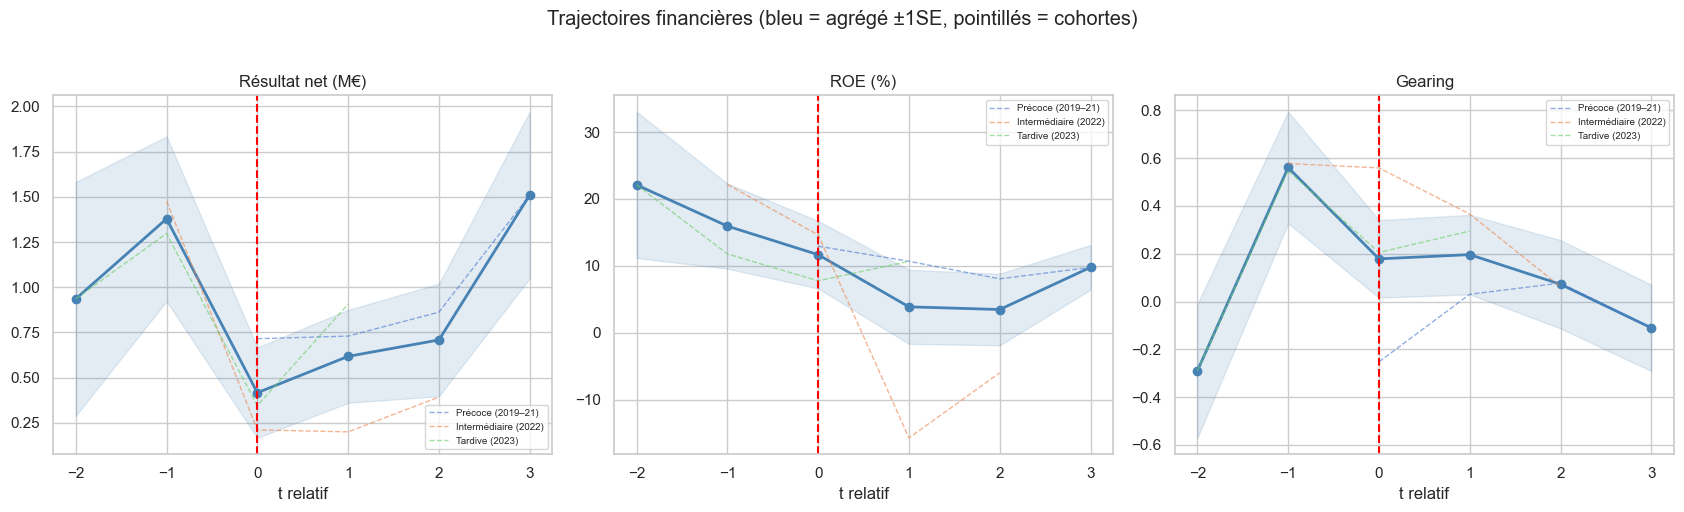

In [9]:
# Trajectoires en temps relatif + hétérogénéité par cohorte
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
outcomes_ts = [('res_net_m','Résultat net (M€)'),('roe','ROE (%)'),('gearing','Gearing')]

df_win = df[df['t_rel'].between(-3,3)]
grouped = df_win.groupby('t_rel')

for ax, (var, label) in zip(axes, outcomes_ts):
    mu = grouped[var].mean(); se = grouped[var].sem()
    ax.plot(mu.index, mu.values, marker='o', color='steelblue', lw=2)
    ax.fill_between(mu.index, mu-se, mu+se, alpha=0.15, color='steelblue')
    for cohort, cdata in df_win[df_win['cohort_group'].notna()].groupby('cohort_group', observed=True):
        tr = cdata.groupby('t_rel')[var].mean()
        ax.plot(tr.index, tr.values, linestyle='--', lw=1, alpha=0.6, label=str(cohort))
    ax.axvline(0, color='red', linestyle='--', lw=1.5)
    ax.set_title(label); ax.set_xlabel('t relatif'); ax.legend(fontsize=7)

plt.suptitle('Trajectoires financières (bleu = agrégé ±1SE, pointillés = cohortes)', y=1.02)
plt.tight_layout(); plt.show()

---
## 4. TWFE — Spécification de référence

Un modèle TWFE (Two-Way Fixed Effects) est un modèle économétrique utilisé avec des données de panel qui inclut à la fois des effets fixes individuels et des effets fixes temporels afin de contrôler les facteurs non observés susceptibles de biaiser l’estimation.

$$Y_{it} = \beta \cdot \text{Post}_{it} + \gamma' X_t + \mu_i + \lambda_t + \varepsilon_{it}$$

**Limites connues de ce TWFE :**
- En design *staggered*, l'estimateur TWFE agrège des comparaisons 2×2 hétérogènes entre cohortes. Si les effets varient dans le temps (hypothèse vraisemblable ici), l'estimateur peut être biaisé (Goodman-Bacon, 2021).
- Ce résultat est conservé comme **référence historique**. La section 6 (C&S) constitue la spécification principale.

In [10]:
def run_fe(outcome, df_p, macro_vars):
    """PanelOLS TWFE avec EF firme + année, erreurs clusterisées firme."""
    cols = [outcome, 'post'] + macro_vars
    sub  = df_p[cols].dropna()
    formula = f'{outcome} ~ post + {" + ".join(macro_vars)} + EntityEffects + TimeEffects'
    res = PanelOLS.from_formula(formula, data=sub, drop_absorbed=True)\
                  .fit(cov_type='clustered', cluster_entity=True)
    if 'post' not in res.params.index:
        print(f"  [{outcome}] 'post' absorbé — ignoré.")
        return None
    return res

OUTCOMES = {
    'Résultat net (M€)':    'res_net_m',
    'CA (M€)':              'ca_m',
    'EBIT (M€)':            'ebit_m',
    'ROE (%)':              'roe',
    'Rentabilité éco. (%)': 'renta_eco',
    'Gearing':              'gearing',
}

results = {}
for label, var in OUTCOMES.items():
    try:
        res = run_fe(var, df_panel, MACRO_FULL)
        if res is not None:
            results[label] = res
    except Exception as e:
        print(f"[{label}] {e}")

rows = []
for label, res in results.items():
    b, se, p = res.params['post'], res.std_errors['post'], res.pvalues['post']
    sig = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else 'n.s.'
    rows.append({'Variable': label, 'β(post)': round(b,4), 'SE': round(se,4),
                 'p-value': round(p,4), 'Sig.': sig,
                 'N obs': int(res.nobs), 'N firmes': int(res.entity_info.total),
                 'R²-within': round(res.rsquared_within,3)})

res_df = pd.DataFrame(rows).set_index('Variable')

def color_sig(val):
    c = {'***':'background-color:#d4edda;font-weight:bold',
         '**':'background-color:#d1ecf1;font-weight:bold',
         '*':'background-color:#fff3cd','n.s.':'color:#6c757d'}
    return c.get(val,'')

def color_beta(val):
    if isinstance(val, float):
        return 'color:#c0392b;font-weight:bold' if val<0 else 'color:#27ae60;font-weight:bold'
    return ''

display(
    res_df.style
        .applymap(color_sig, subset=['Sig.'])
        .applymap(color_beta, subset=['β(post)'])
        .format({'β(post)':'{:+.4f}','SE':'{:.4f}','p-value':'{:.4f}',
                 'N obs':'{:,}','N firmes':'{:,}'})
        .set_caption("TWFE — Référence uniquement. Voir section 6 pour l'estimateur principal (S&A).")
)
print("*** p<0.01 | ** p<0.05 | * p<0.1 | n.s. non sig.")

,β(post),SE,p-value,Sig.,N obs,N firmes,R²-within
Variable,,,,,,,
Résultat net (M€),-0.8935,0.5493,0.1040,n.s.,"2,065",615,0.001000
CA (M€),+6.6011,6.2715,0.2929,n.s.,"1,253",413,0.012000
EBIT (M€),-0.0267,0.5262,0.9596,n.s.,"1,305",420,0.000000
ROE (%),+3.7085,11.0817,0.7380,n.s.,"1,296",420,-0.003000
Rentabilité éco. (%),-0.0542,0.0189,0.0042,***,"1,787",552,0.012000
Gearing,-0.1436,0.3296,0.6631,n.s.,"2,011",607,-0.000000


*** p<0.01 | ** p<0.05 | * p<0.1 | n.s. non sig.


---
## 5. Event Study TWFE

On estime ici un effet dynamique du traitement avec une event study en TWFE en comparant chaque période à t = −1 (référence), après avoir regroupé les périodes extrêmes pour plus de robustesse. L’objectif est de tester les tendances parallèles (coefficients pré-traitement ≈ 0) et de mesurer l’évolution de l’effet causal après l’événement, tout en contrôlant les effets fixes et des variables macroéconomiques avec des erreurs standards clusterisées. 

PS : Les erreurs standards clusterisées corrigent le fait que les observations d’une même firme sont corrélées dans le temps, ce qui évite de sous-estimer l’incertitude et de surestimer la significativité.

  [res_net_m] Dummies sans variance (absorbées) : ['es_m3']
  [res_net_m] Dummy t=-3 absorbée par les EF — exclue du graphique.
  [roe] Dummies sans variance (absorbées) : ['es_m3']
  [roe] Dummy t=-3 absorbée par les EF — exclue du graphique.
  [gearing] Dummies sans variance (absorbées) : ['es_m3']
  [gearing] Dummy t=-3 absorbée par les EF — exclue du graphique.


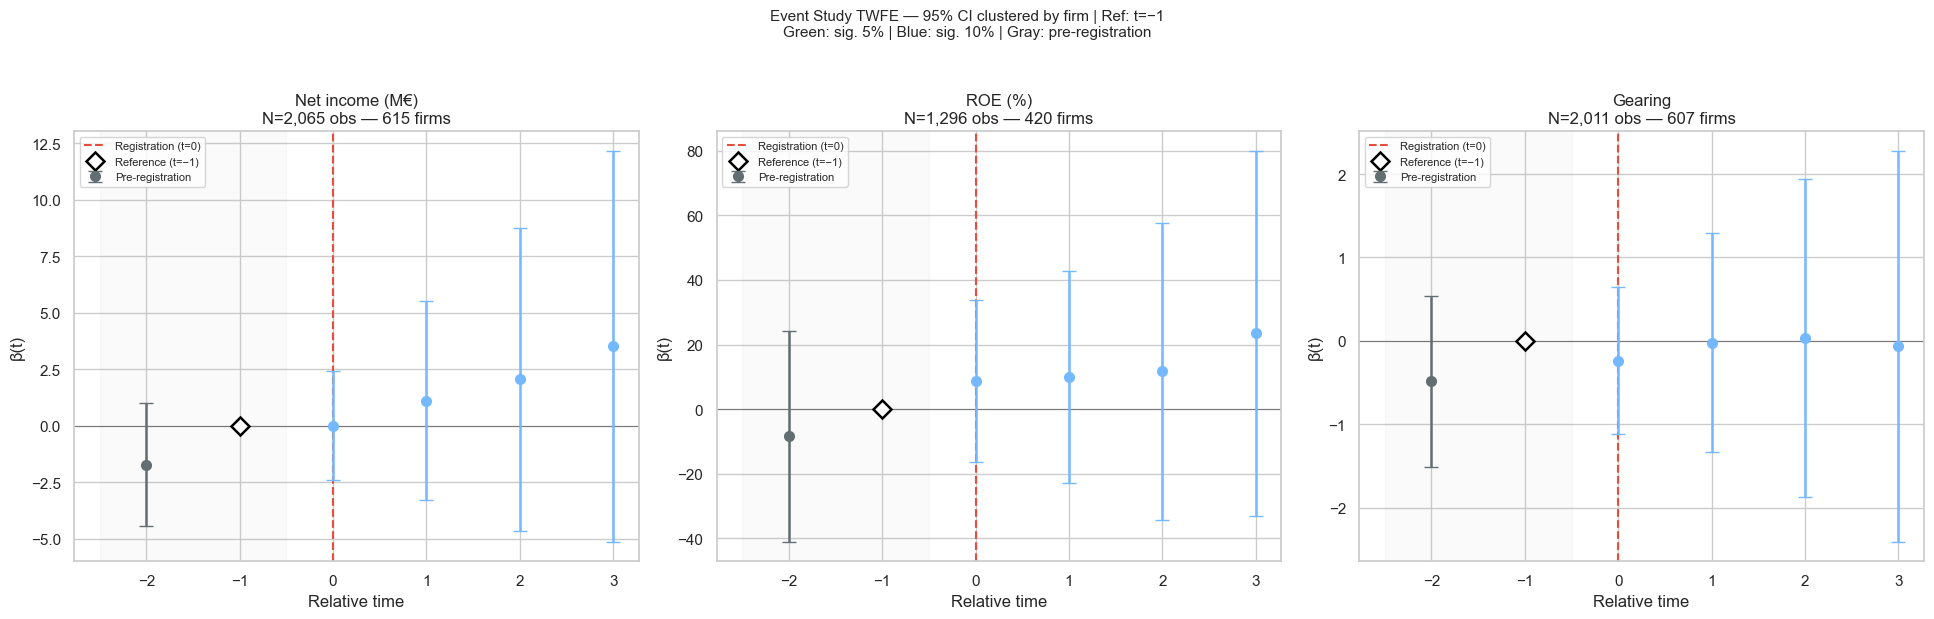

In [11]:
ES_WINDOW = range(-3, 4)
T_REF     = -1

df['t_rel_clamp'] = df['t_rel'].clip(lower=-3, upper=3)
T_DUMMIES = [t for t in ES_WINDOW if t != T_REF]

for t in T_DUMMIES:
    col = f'es_{t}' if t >= 0 else f'es_m{abs(t)}'
    df[col] = (df['t_rel_clamp'] == t).astype(int)

dummy_cols_es = [f'es_{t}' if t >= 0 else f'es_m{abs(t)}' for t in T_DUMMIES]
df_panel = df.set_index(['siren', 'annee'])

def run_event_study(outcome, df_p, dummy_cols, macro_vars, t_dummies, t_ref=-1):
    cols = [outcome] + dummy_cols + macro_vars
    sub  = df_p[cols].dropna()
    if sub.index.get_level_values(0).nunique() < 20:
        print(f'  [{outcome}] Trop peu de firmes : {sub.index.get_level_values(0).nunique()}')
        return None
    # Vérifier que les dummies ont de la variance (pas entièrement absorbées)
    dummy_var = sub[dummy_cols].var()
    zero_var  = dummy_var[dummy_var == 0].index.tolist()
    if zero_var:
        print(f'  [{outcome}] Dummies sans variance (absorbées) : {zero_var}')
        dummy_cols = [c for c in dummy_cols if c not in zero_var]
        if not dummy_cols:
            print(f'  [{outcome}] Toutes les dummies absorbées — event study impossible.')
            return None
    formula = (f'{outcome} ~ {" + ".join(dummy_cols)} + '
               f'{" + ".join(macro_vars)} + EntityEffects + TimeEffects')
    try:
        res = PanelOLS.from_formula(formula, data=sub, drop_absorbed=True)\
                      .fit(cov_type='clustered', cluster_entity=True)
    except Exception as e:
        print(f'  [{outcome}] Erreur modèle : {e}'); return None
    rows = []
    for t in sorted(set(list(t_dummies) + [t_ref])):
        col = f'es_{t}' if t >= 0 else f'es_m{abs(t)}'
        if t == t_ref:
            rows.append({'t_rel':t,'coef':0.,'ci_lo':0.,'ci_hi':0.,'pval':np.nan,'ref':True})
        elif col in res.params.index:
            ci = res.conf_int().loc[col]
            rows.append({'t_rel':t,'coef':res.params[col],'ci_lo':ci.iloc[0],
                         'ci_hi':ci.iloc[1],'pval':res.pvalues[col],'ref':False})
        else:
            print(f'  [{outcome}] Dummy t={t} absorbée par les EF — exclue du graphique.')
    if not rows:
        return None
    es = pd.DataFrame(rows).sort_values('t_rel').reset_index(drop=True)
    es['n_obs'] = res.nobs; es['n_firms'] = res.entity_info.total
    return es, res

ES_OUTCOMES = {'Net income (M€)':'res_net_m', 'ROE (%)':'roe', 'Gearing':'gearing'}
es_results = {}
for label, var in ES_OUTCOMES.items():
    out = run_event_study(var, df_panel, dummy_cols_es, MACRO_FULL, T_DUMMIES)
    if out:
        es_results[label] = out

# ── Diagnostic si aucun résultat ──────────────────────────────────
if not es_results:
    print()
    print("⚠  es_results est vide — aucun event study estimable.")
    print("   Cause probable : avec seulement 4 années (2021–2024) et une fenêtre ±3,")
    print("   les dummies pré-traitement (t=-3, t=-2) sont quasi-vides ou colinéaires")
    print("   avec les effets fixes année.")
    print()
    print("   Distribution de t_rel dans le panel :")
    print(df['t_rel'].value_counts().sort_index().to_string())
    print()
    print("   → Passage à une fenêtre réduite ±2 ans.")

    ES_WINDOW_2 = range(-2, 3)
    T_DUMMIES_2 = [t for t in ES_WINDOW_2 if t != T_REF]
    df['t_rel_clamp2'] = df['t_rel'].clip(lower=-2, upper=2)
    for t in T_DUMMIES_2:
        col = f'es2_{t}' if t >= 0 else f'es2_m{abs(t)}'
        df[col] = (df['t_rel_clamp2'] == t).astype(int)
    dummy_cols_es2 = [f'es2_{t}' if t >= 0 else f'es2_m{abs(t)}' for t in T_DUMMIES_2]
    df_panel = df.set_index(['siren', 'annee'])

    for label, var in ES_OUTCOMES.items():
        out = run_event_study(var, df_panel, dummy_cols_es2, MACRO_FULL, T_DUMMIES_2)
        if out:
            es_results[label] = out

# ── Event Study plots ─────────────────────────────────────────────
if not es_results:
    print("⚠  Aucun event study estimable même en fenêtre ±2.")
    print("   Raison : la variation temporelle est insuffisante dans ce panel (2021–2024).")
    print("   L'identification repose entièrement sur le TWFE (section 4) et Sun & Abraham (section 6).")
else:
    n_plots = len(es_results)
    fig, axes = plt.subplots(1, n_plots, figsize=(6.5*n_plots, 6))
    if n_plots == 1: axes = [axes]

    for ax, (label, (es_df, _)) in zip(axes, es_results.items()):
        pre  = es_df[es_df['t_rel'] < 0]
        post = es_df[es_df['t_rel'] >= 0]
        ref_row = es_df[es_df['ref']]
        ax.axvspan(es_df['t_rel'].min() - 0.5, -0.5, alpha=0.04, color='gray')
        ax.axhline(0, color='black', lw=0.8, alpha=0.4)
        ax.axvline(0, color='#e74c3c', lw=1.5, linestyle='--', label='Registration (t=0)')
        non_ref_pre = pre[~pre['ref']]
        if not non_ref_pre.empty:
            ax.errorbar(non_ref_pre['t_rel'], non_ref_pre['coef'],
                        yerr=[non_ref_pre['coef']-non_ref_pre['ci_lo'],
                              non_ref_pre['ci_hi']-non_ref_pre['coef']],
                        fmt='o', color='#636e72', capsize=5, lw=1.8, ms=7, label='Pre-registration')
        for _, row in post[~post['ref']].iterrows():
            c = '#27ae60' if row['pval']<0.05 else '#2980b9' if row['pval']<0.1 else '#74b9ff'
            ax.errorbar(row['t_rel'], row['coef'],
                        yerr=[[row['coef']-row['ci_lo']],[row['ci_hi']-row['coef']]],
                        fmt='o', color=c, capsize=5, lw=1.8, ms=7)
        ax.plot(ref_row['t_rel'], ref_row['coef'], 'D', color='black', ms=9,
                mfc='white', mew=1.8, zorder=5, label='Reference (t=−1)')
        for _, row in es_df[~es_df['ref']].iterrows():
            if pd.notna(row['pval']):
                sig = '***' if row['pval']<0.01 else '**' if row['pval']<0.05 else '*' if row['pval']<0.1 else ''
                if sig:
                    ax.annotate(sig, xy=(row['t_rel'], row['ci_hi']), xytext=(0,5),
                                textcoords='offset points', ha='center', fontsize=10, color='#c0392b')
        ax.set_title(f"{label}\nN={int(es_df['n_obs'].iloc[0]):,} obs — {int(es_df['n_firms'].iloc[0]):,} firms")
        ax.set_xlabel('Relative time'); ax.set_ylabel('β(t)')
        ax.set_xticks(sorted(es_df['t_rel'].dropna().astype(int).unique()))
        ax.legend(fontsize=8)

    plt.suptitle('Event Study TWFE — 95% CI clustered by firm | Ref: t=−1\n'
                 'Green: sig. 5% | Blue: sig. 10% | Gray: pre-registration',
                 y=1.03, fontsize=11)
    plt.tight_layout(); plt.show()

In [12]:
# Tableau numérique Event Study
for label, (es_df, _) in es_results.items():
    print(f"\nEvent Study — {label}")
    print(f"{'t':>8} {'β(t)':>10} {'CI 95% bas':>12} {'CI 95% haut':>13} {'p-value':>9} {'Sig.':>6}")
    print("-"*60)
    for _, row in es_df.iterrows():
        t_lbl = f't={int(row["t_rel"]):+d}'
        if row['ref']:
            print(f"{t_lbl:>8} {'0.0000':>10} {'(réf)':>12} {'(réf)':>13} {'---':>9} {'<-ref':>6}")
        else:
            sig = '***' if row['pval']<0.01 else '**' if row['pval']<0.05 else '*' if row['pval']<0.1 else 'n.s.'
            print(f"{t_lbl:>8} {row['coef']:>+10.4f} {row['ci_lo']:>12.4f} {row['ci_hi']:>13.4f} {row['pval']:>9.4f} {sig:>6}")


Event Study — Net income (M€)
       t       β(t)   CI 95% bas   CI 95% haut   p-value   Sig.
------------------------------------------------------------
    t=-2    -1.7110      -4.4177        0.9958    0.2152   n.s.
    t=-1     0.0000        (réf)         (réf)       ---  <-ref
    t=+0    +0.0166      -2.4123        2.4454    0.9893   n.s.
    t=+1    +1.1223      -3.3014        5.5461    0.6188   n.s.
    t=+2    +2.0597      -4.6478        8.7672    0.5470   n.s.
    t=+3    +3.5300      -5.1245       12.1845    0.4238   n.s.

Event Study — ROE (%)
       t       β(t)   CI 95% bas   CI 95% haut   p-value   Sig.
------------------------------------------------------------
    t=-2    -8.4232     -41.0328       24.1865    0.6123   n.s.
    t=-1     0.0000        (réf)         (réf)       ---  <-ref
    t=+0    +8.5900     -16.4681       33.6481    0.5012   n.s.
    t=+1    +9.8230     -22.9788       42.6249    0.5568   n.s.
    t=+2   +11.7888     -34.2017       57.7793    0.6150

### 5b. Test formel des pré-tendances (F-test joint)

Le graphique de l'event study fournit une inspection visuelle des tendances parallèles, mais un **test statistique formel** est requis dans tout papier empirique. On réalise ici un test de Wald joint sur l'hypothèse nulle :

$$H_0 : \beta_{t-3} = \beta_{t-2} = 0$$

*(t=−1 étant la référence exclue, les périodes pré-traitement testables sont t=−3 et t=−2)*

Un p-value élevé (> 0,1) est cohérent avec l'hypothèse de tendances parallèles. Un p-value faible (< 0,05) remet en cause la validité du design DiD.

In [13]:
# ── F-test joint sur les coefficients pré-traitement ─────────────────
print("Test formel des pré-tendances — H0 : β(t-3) = β(t-2) = 0")
print("=" * 65)

pre_dummy_cols = ['es_m3', 'es_m2']  # t=-3 et t=-2 (t=-1 est la référence)

for label, (es_df, res_obj) in es_results.items():
    available_pre = [c for c in pre_dummy_cols if c in res_obj.params.index]
    if len(available_pre) == 0:
        print(f"  [{label}] Aucun coefficient pré disponible — ignoré.")
        continue

    betas = res_obj.params[available_pre].values
    vcov  = res_obj.cov.loc[available_pre, available_pre].values
    k = len(betas)

    try:
        vcov_inv = np.linalg.inv(vcov)
        W = float(betas @ vcov_inv @ betas)
        p_chi2 = 1 - scipy_stats.chi2.cdf(W, df=k)
        F_stat = W / k
        p_F    = 1 - scipy_stats.f.cdf(F_stat, dfn=k, dfd=res_obj.df_resid)

        verdict = ('Tendances parallèles non rejetées' if p_F > 0.1
                   else ('Marginalement fragile' if p_F > 0.05
                   else 'Tendances parallèles REJETÉES — design fragilisé'))

        print(f"  {label}")
        print(f"    Coefficients testés : {available_pre}")
        print(f"    β = {np.round(betas, 4)}")
        print(f"    F({k}, {int(res_obj.df_resid)}) = {F_stat:.4f}   p-value = {p_F:.4f}")
        print(f"    χ²({k}) = {W:.4f}              p-value = {p_chi2:.4f}")
        print(f"    → {verdict}")
        print()
    except np.linalg.LinAlgError:
        print(f"  [{label}] Matrice de covariance singulière — test impossible.")

print("Note : test basé sur erreurs clusterisées firme, cohérent avec le modèle TWFE.")
print("Seconde note : Un p-value > 0.1 est cohérent avec H0 (tendances parallèles).")

Test formel des pré-tendances — H0 : β(t-3) = β(t-2) = 0
  Net income (M€)
    Coefficients testés : ['es_m2']
    β = [-1.711]
    F(1, 1442) = 1.5375   p-value = 0.2152
    χ²(1) = 1.5375              p-value = 0.2150
    → Tendances parallèles non rejetées

  ROE (%)
    Coefficients testés : ['es_m2']
    β = [-8.4232]
    F(1, 868) = 0.2570   p-value = 0.6123
    χ²(1) = 0.2570              p-value = 0.6122
    → Tendances parallèles non rejetées

  Gearing
    Coefficients testés : ['es_m2']
    β = [-0.4831]
    F(1, 1396) = 0.8565   p-value = 0.3549
    χ²(1) = 0.8565              p-value = 0.3547
    → Tendances parallèles non rejetées

Note : test basé sur erreurs clusterisées firme, cohérent avec le modèle TWFE.
Seconde note : Un p-value > 0.1 est cohérent avec H0 (tendances parallèles).


---
## 6. Estimateur Sun & Abraham *(spécification principale)*

**Pourquoi Sun & Abraham plutôt que TWFE ?** Dans un design staggered, le TWFE agrège des comparaisons 2×2 entre cohortes avec des poids qui peuvent être négatifs si les effets varient dans le temps (Goodman-Bacon, 2021). L'estimateur de Sun & Abraham (2021) estime des ATT(g,t) — l'effet pour chaque cohorte g à chaque période t — puis les agrège sans poids négatifs.

**Implémentation** : feols('y ~ i(t_rel, cohort, ref=-1) | siren + annee') avec erreurs clusterisées firme. Certains ATT(g,t) sont non identifiables (cohorte sans observations suffisantes sur une période) et sont exclus de l'agrégation — c'est attendu et signalé.

**Sans groupe never-treated** : les cohortes tardives servent de contrefactuel aux cohortes précoces avant leur propre inscription. Cette hypothèse est partagée avec le TWFE, mais S&A la rend plus transparente en estimant les effets cohorte par cohorte.

In [14]:
import re
sa_results = {}

for label, var in [('Résultat net (M€)', 'res_net_m'),
                    ('ROE (%)',           'roe'),
                    ('Gearing',           'gearing')]:

    df_sa = df[['siren','annee','annee_mission','cohort_group', var]].dropna(subset=[var]).copy()
    df_sa['t_rel']  = (df_sa['annee'] - df_sa['annee_mission']).clip(-3, 3)
    df_sa['cohort'] = df_sa['annee_mission'].astype(str)

    if df_sa['siren'].nunique() < 20:
        print(f"  [{label}] Trop peu de firmes."); continue

    try:
        fit = pf.feols(
            f'{var} ~ i(t_rel, cohort, ref=-1) | siren + annee',
            data   = df_sa,
            vcov   = {'CRV1': 'siren'},
        )
        tidy = fit.tidy().copy()

        tidy['t_val'] = tidy.index.map(
            lambda s: int(re.search(r't_rel::(-?\d+):', s).group(1))
                       if re.search(r't_rel::(-?\d+):', s) else np.nan
        )
        tidy['cohort_lbl'] = tidy.index.map(
            lambda s: re.search(r'cohort::(\d+)', s).group(1)
                      if re.search(r'cohort::(\d+)', s) else '?'
        )

        post_coefs = tidy[tidy['t_val'] >= 0]
        pre_coefs  = tidy[tidy['t_val'] <  0]

        # Agrégation pondérée par N obs par cohorte × période
        # (remplace la moyenne simple de v3 — évite de surpondérer les petites cohortes)
        cohort_counts = df_sa.groupby(['cohort', 't_rel'])['siren'].count().reset_index()
        cohort_counts.columns = ['cohort_lbl', 't_val', 'n_obs']
        cohort_counts['cohort_lbl'] = cohort_counts['cohort_lbl'].astype(str)

        post_merged = post_coefs.merge(cohort_counts, on=['cohort_lbl','t_val'], how='left')
        pre_merged  = pre_coefs.merge(cohort_counts,  on=['cohort_lbl','t_val'], how='left')

        att_global = np.average(post_merged['Estimate'], weights=post_merged['n_obs'].fillna(1)) \
                     if len(post_merged) > 0 else np.nan
        pre_mean   = np.average(pre_merged['Estimate'],  weights=pre_merged['n_obs'].fillna(1)) \
                     if len(pre_merged) > 0 else np.nan

        collin = getattr(fit, '_collin_vars', [])
        n_drop = len(collin) if collin else 0

        sa_results[label] = {
            'tidy':       tidy,
            'att_global': att_global,
            'pre_mean':   pre_mean,
            'n_dropped':  collin,
        }
        print(f"[{label}] ATT pondéré post = {att_global:+.4f} "
              f"| Pré pondéré = {pre_mean:+.4f} "
              f"| {n_drop} ATT(g,t) droppés")

    except Exception as e:
        print(f"  ❌ [{label}] {e}")

[Résultat net (M€)] ATT pondéré post = -1.0237 | Pré pondéré = +1.8054 | 14 ATT(g,t) droppés
[ROE (%)] ATT pondéré post = -1.7997 | Pré pondéré = -31.6289 | 14 ATT(g,t) droppés
[Gearing] ATT pondéré post = -0.0385 | Pré pondéré = -0.1280 | 14 ATT(g,t) droppés


Variable                     ATT S&A   ATT TWFE   Δ (S&A−TWFE) Interpretation
-------------------------------------------------------------------------------------
Résultat net (M€)            -1.0237    -0.8935        -0.1303  ✅ Convergent
ROE (%)                      -1.7997    +3.7085        -5.5082  ⚠ Cohort heterogeneity
Gearing                      -0.0385    -0.1436        +0.1052  ⚠ Cohort heterogeneity
-------------------------------------------------------------------------------------

Note: ATT S&A = weighted by N obs cohort × period.
Non-identifiable ATT(g,t) are excluded.
If Δ > 20% of TWFE: TWFE is biased by heterogeneity — prefer S&A.


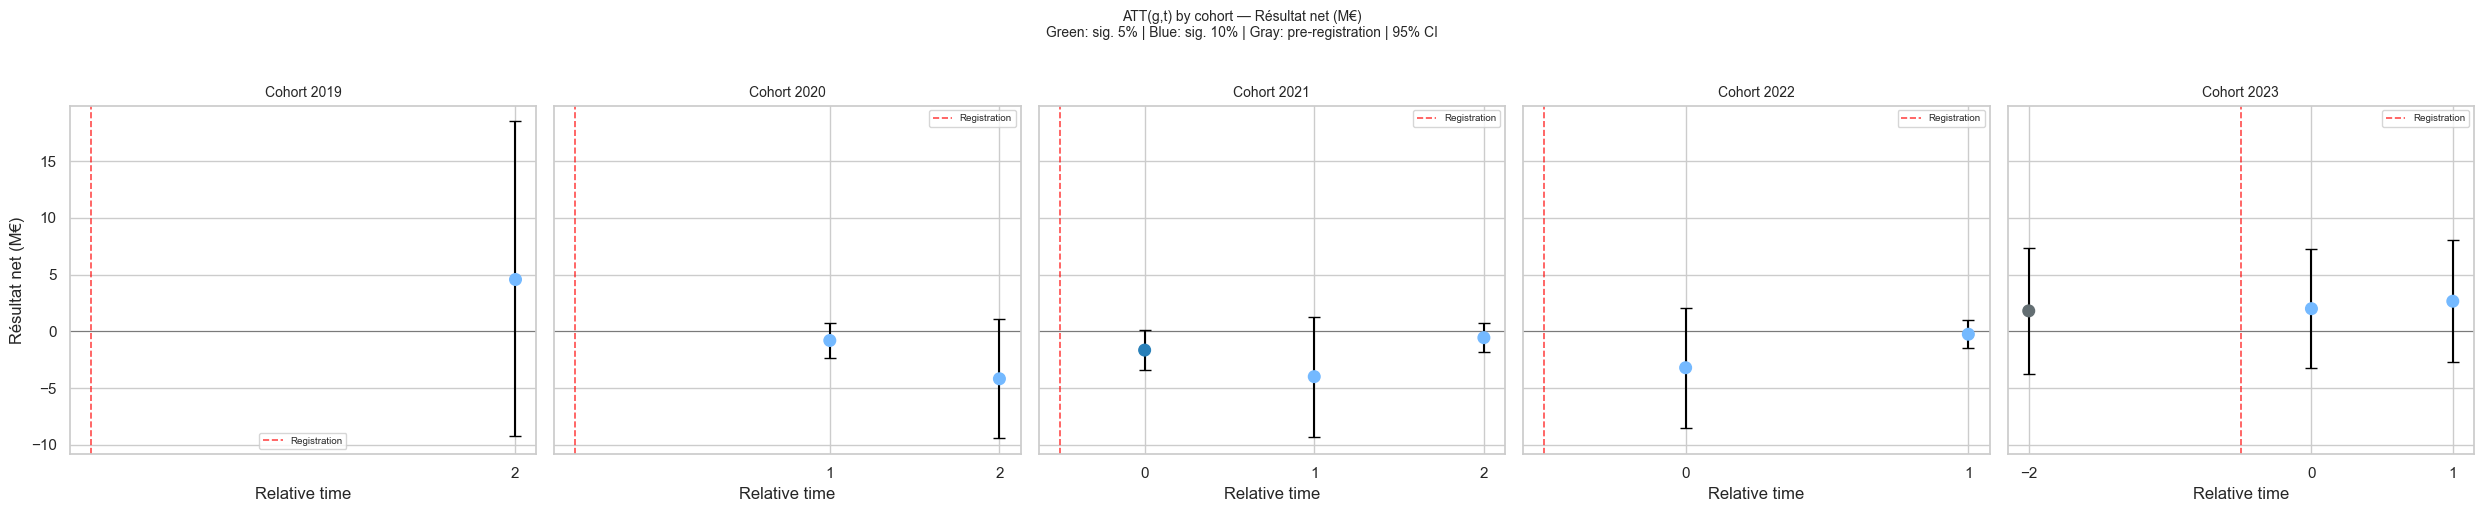

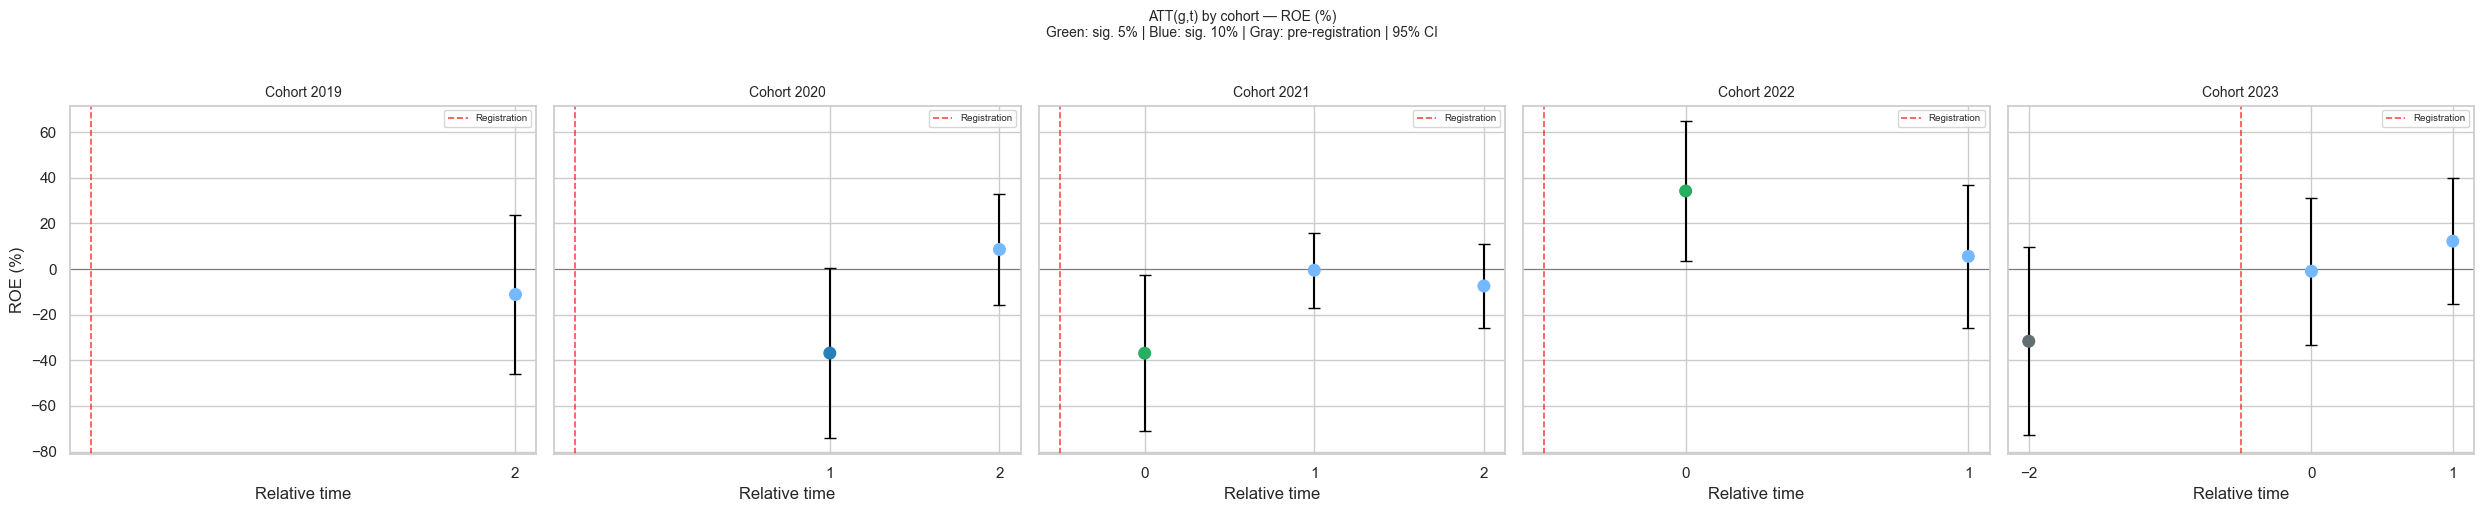

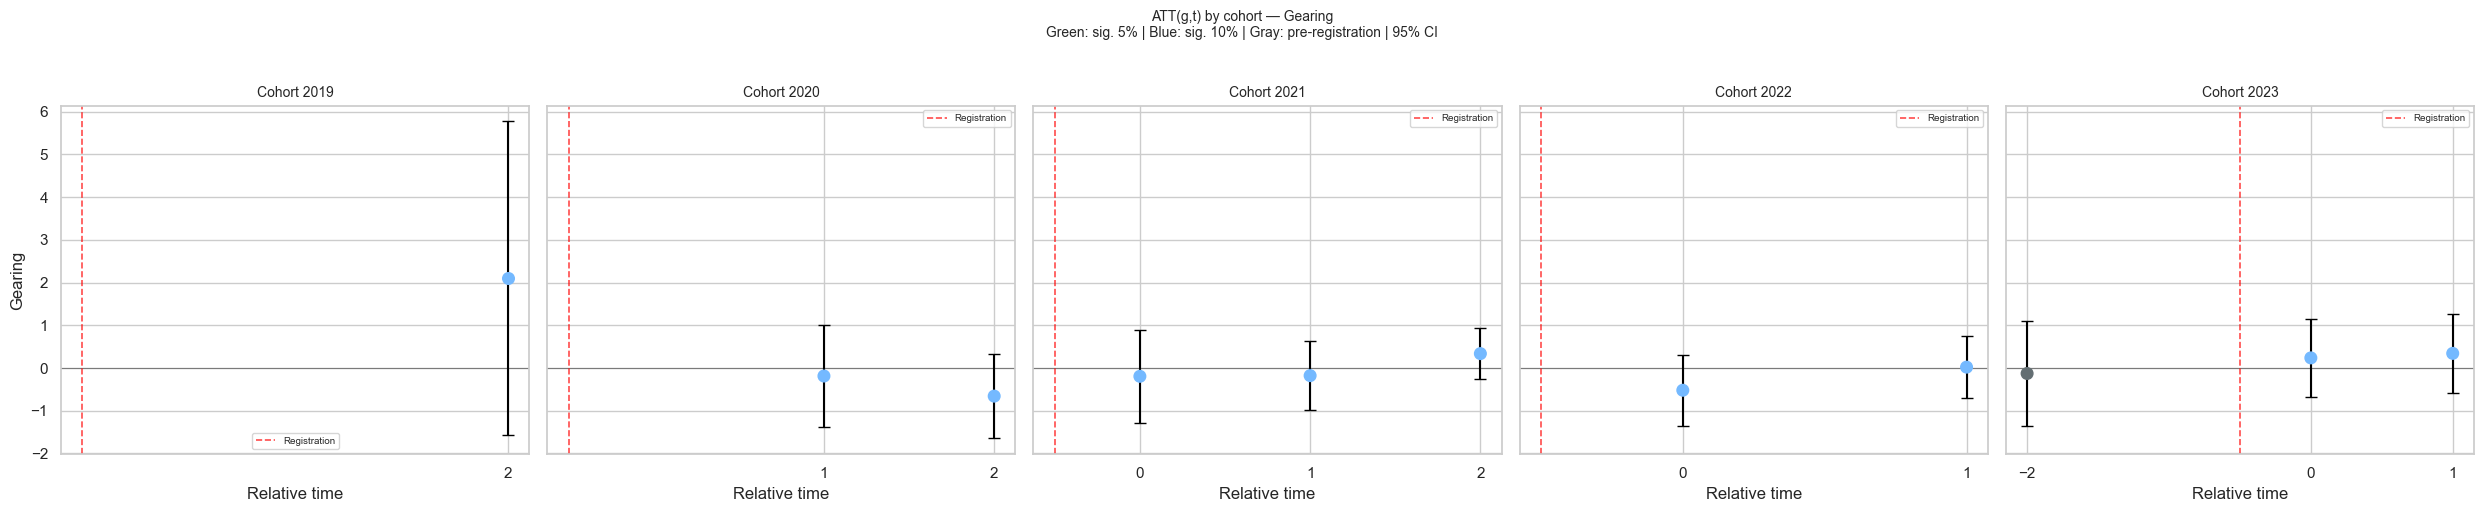

In [15]:
# ── Aggregated ATT(g,t) summary table ─────────────────────────────────
print(f"{'Variable':25} {'ATT S&A':>10} {'ATT TWFE':>10} {'Δ (S&A−TWFE)':>14} {'Interpretation'}")
print("-"*85)
for label, res in sa_results.items():
    att_sa   = res['att_global']
    att_twfe = results[label].params['post'] if label in results else np.nan
    delta    = att_sa - att_twfe
    interp   = '⚠ Cohort heterogeneity' if abs(delta) > abs(att_twfe)*0.2 else '✅ Convergent'
    print(f"{label:25} {att_sa:>+10.4f} {att_twfe:>+10.4f} {delta:>+14.4f}  {interp}")
print("-"*85)
print("\nNote: ATT S&A = weighted by N obs cohort × period.")
print("Non-identifiable ATT(g,t) are excluded.")
print("If Δ > 20% of TWFE: TWFE is biased by heterogeneity — prefer S&A.")

# ── ATT(g,t) by cohort plot ───────────────────────────────────────────
for label, res in sa_results.items():
    tidy = res['tidy'].dropna(subset=['t_val']).copy()
    cohorts_u = sorted(tidy['cohort_lbl'].unique())
    n_coh = len(cohorts_u)
    if n_coh == 0:
        print(f"  [{label}] No cohort identified."); continue
    fig, axes = plt.subplots(1, n_coh, figsize=(5*n_coh, 5), sharey=True)
    if n_coh == 1: axes = [axes]
    for ax, coh in zip(axes, cohorts_u):
        sub = tidy[tidy['cohort_lbl'] == coh].sort_values('t_val')
        if sub.empty:
            ax.set_visible(False); continue
        pval_col  = 'Pr(>|t|)' if 'Pr(>|t|)' in sub.columns else 'pvalue'
        ci_lo_col = '2.5%'  if '2.5%'  in sub.columns else 'ci_low'
        ci_hi_col = '97.5%' if '97.5%' in sub.columns else 'ci_high'
        colors = ['#636e72' if t < 0
                  else ('#27ae60' if p < 0.05 else ('#2980b9' if p < 0.1 else '#74b9ff'))
                  for t, p in zip(sub['t_val'], sub[pval_col])]
        ax.errorbar(sub['t_val'], sub['Estimate'],
                    yerr=[sub['Estimate']-sub[ci_lo_col], sub[ci_hi_col]-sub['Estimate']],
                    fmt='none', color='black', capsize=4, lw=1.5, zorder=3)
        ax.scatter(sub['t_val'], sub['Estimate'], c=colors, s=70, zorder=4)
        ax.axhline(0, color='black', lw=0.8, alpha=0.4)
        ax.axvline(-0.5, color='red', lw=1.2, linestyle='--', alpha=0.7, label='Registration')
        ax.set_title(f'Cohort {coh}', fontsize=10)
        ax.set_xlabel('Relative time')
        ax.set_xticks(sorted(sub['t_val'].dropna().astype(int).unique()))
        ax.legend(fontsize=7)
    axes[0].set_ylabel(label)
    plt.suptitle(f'ATT(g,t) by cohort — {label}\n'
                 'Green: sig. 5% | Blue: sig. 10% | Gray: pre-registration | 95% CI',
                 y=1.02, fontsize=10)
    plt.tight_layout()
    plt.show()

In [16]:
# Synthèse finale de la comparaison TWFE vs Sun & Abraham
print("=" * 65)
print("SYNTHÈSE : TWFE vs Sun & Abraham — Résultat net (M€)")
print("=" * 65)
label = 'Résultat net (M€)'
if label in results and label in sa_results:
    b_twfe  = results[label].params['post']
    p_twfe  = results[label].pvalues['post']
    b_sa    = sa_results[label]['att_global']
    pre_sa  = sa_results[label]['pre_mean']
    print(f"  TWFE classique   : β = {b_twfe:+.4f}  (p = {p_twfe:.4f})")
    print(f"  Sun & Abraham    : ATT = {b_sa:+.4f}  (agrégation simple)")
    print(f"  Pré-tendance S&A : {pre_sa:+.4f}  (doit être ≈ 0)")
    print()
    delta = abs(b_sa - b_twfe)
    if delta > abs(b_twfe) * 0.2:
        print(f"Divergence de {delta:.4f} ({100*delta/abs(b_twfe):.0f}% du TWFE)")
        print("  → Hétérogénéité des effets par cohorte détectée.")
        print("  → Privilégier S&A. Le TWFE agrège avec des poids potentiellement négatifs.")
    else:
        print(f"Convergence (Δ = {delta:.4f}) — résultats cohérents entre estimateurs.")
    print()
    if abs(pre_sa) > 0.1 * abs(b_sa) if b_sa != 0 else abs(pre_sa) > 0.05:
        print("Pré-tendances non nulles en S&A — hypothèse d'identification fragile.")
    else:
        print("Pré-tendances proches de zéro — identification crédible.")

SYNTHÈSE : TWFE vs Sun & Abraham — Résultat net (M€)
  TWFE classique   : β = -0.8935  (p = 0.1040)
  Sun & Abraham    : ATT = -1.0237  (agrégation simple)
  Pré-tendance S&A : +1.8054  (doit être ≈ 0)

Convergence (Δ = 0.1303) — résultats cohérents entre estimateurs.

Pré-tendances non nulles en S&A — hypothèse d'identification fragile.


---
## 7. Analyse de robustesse

Six spécifications testées sur l'outcome principal (résultat net). Une correction pour tests multiples (Bonferroni) est appliquée sur les analyses sectorielles.

In [17]:
# Winsorisation alternative P5–P95
df_p5 = df.copy()
for col in WINSOR_VARS:
    lo5, hi5 = df_p5[col].quantile(0.05), df_p5[col].quantile(0.95)
    df_p5[col] = df_p5[col].clip(lo5, hi5)
df_p5['res_net_m'] = df_p5['res_net'] / 1e6

obs_post_3 = df[df['t_rel']>=0].groupby('siren').size()
valid3 = obs_post_3[obs_post_3 >= 3].index

rob_specs = [
    ('Spec. principale (W P1–P99)',           df_panel,                                       'res_net_m', MACRO_FULL),
    ('Contrôles parcimonieux',                df_panel,                                       'res_net_m', MACRO_PARCI),
    ('Winsorisation P5–P95',                  df_p5.set_index(['siren','annee']),              'res_net_m', MACRO_FULL),
    ('Fenêtre ±2 ans',                        df[df['t_rel'].between(-2,2)].set_index(['siren','annee']), 'res_net_m', MACRO_FULL),
    ('Cohortes précoces ≤2021',               df[df['annee_mission']<=2021].set_index(['siren','annee']),'res_net_m', MACRO_FULL),
    ('Seuil ≥3 obs post',                     df[df['siren'].isin(valid3)].set_index(['siren','annee']),  'res_net_m', MACRO_FULL),
    ('log(Rés. net) — ⚠ sous-ech. rentables', df_panel,                                       'log_res_net', MACRO_FULL),
]

print(f"{'Spécification':48} {'β(post)':>10} {'p-value':>9} {'Sig.':>5} {'N obs':>7} {'N firmes':>9}")
print("-"*90)
for name, dp, var, macro in rob_specs:
    try:
        res = run_fe(var, dp, macro)
        if res is None: print(f"{name:48} ⚠ 'post' absorbé"); continue
        b, p = res.params['post'], res.pvalues['post']
        sig = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else 'n.s.'
        print(f"{name:48} {b:+10.4f} {p:9.4f} {sig:>5} {res.nobs:>7.0f} {res.entity_info.total:>9.0f}")
    except Exception as e:
        print(f"{name:48} ERREUR : {e}")
        
print("\nL'ensemble des spécifications se basent sur la variable du Résultat net.")
print("log(Rés. net) : sous-échantillon biaisé vers firmes rentables — non comparable aux niveaux.")

Spécification                                       β(post)   p-value  Sig.   N obs  N firmes
------------------------------------------------------------------------------------------
Spec. principale (W P1–P99)                         -0.8935    0.1040  n.s.    2065       615
Contrôles parcimonieux                              -0.8935    0.1040  n.s.    2065       615
Winsorisation P5–P95                                -0.1783    0.3480  n.s.    2065       615
Fenêtre ±2 ans                                      -0.9144    0.1373  n.s.    1748       612
Cohortes précoces ≤2021                          ERREUR : exog does not have full column rank. If you wish to proceed with model estimation irrespective of the numerical accuracy of coefficient estimates, you can set check_rank=False.
Seuil ≥3 obs post                                   -0.6448    0.4680  n.s.    1259       346
log(Rés. net) — ⚠ sous-ech. rentables               -0.2757    0.0776     *    1301       482

L'ensemble des 

In [19]:
# ── Robustesse par secteur EcoVadis (top 5 secteurs) ──────────────────────────
# Note : la nouvelle BDD ne contient pas de code NAF/APE.
# Le secteur est proxié par Secteur_EcoVadis (variable catégorielle).
MIN_CLUSTERS = 25

top_secteurs = df['secteur'].value_counts().head(5).index

print(f"{'Secteur':35} {'β(post)':>10} {'p-value':>9} {'Sig.':>5} {'N obs':>7} {'N firmes':>9}")
print("-" * 90)

for sec in top_secteurs:
    df_sec  = df[df['secteur'] == sec]
    n_firms = df_sec['siren'].nunique()

    if n_firms < MIN_CLUSTERS:
        print(f"{str(sec)[:35]:35} {'—':>10} {'—':>9} {'—':>5} {'—':>7} {n_firms:>9}  "
              f"⚠ Trop peu de clusters ({n_firms} < {MIN_CLUSTERS})")
        continue

    try:
        res_sec = run_fe('res_net_m', df_sec.set_index(['siren', 'annee']), MACRO_FULL)

        if res_sec is None:
            print(f"{str(sec)[:35]:35} ⚠ 'post' absorbé — ignoré")
            continue

        b      = res_sec.params['post']
        p      = res_sec.pvalues['post']
        n_obs  = res_sec.nobs
        n_firm = res_sec.entity_info.total
        sig    = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else 'n.s.'
        print(f"{str(sec)[:35]:35} {b:+10.4f} {p:9.4f} {sig:>5} {n_obs:>7.0f} {n_firm:>9.0f}")

    except Exception as e:
        print(f"{str(sec)[:35]:35} ERREUR : {e}")

Secteur                                β(post)   p-value  Sig.   N obs  N firmes
------------------------------------------------------------------------------------------
Finance, Legal & Consulting            -1.8490    0.0606     *     877       260
Wholesale, Services & Professionals    -1.6120    0.1077  n.s.     539       161
Food & Beverage                        +2.0333    0.2966  n.s.     215        65
ICT                                    +0.4467    0.2734  n.s.     205        61
Transport                              +0.6400    0.8296  n.s.      87        26


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# TABLEAU DE SÉLECTION D'ÉCHANTILLON — Annexe
# Ce tableau retrace la réduction progressive des observations depuis le dataset
# initial jusqu'aux sous-échantillons utilisés dans chaque spécification.
# ─────────────────────────────────────────────────────────────────────────────

rows_selection = []

# ── Étape 1 : Dataset brut ───────────────────────────────────────────────────
rows_selection.append({
    'Étape': '1. Dataset initial (après scraping)',
    'N obs': len(df_raw),
    'N firmes': df_raw['siren'].nunique(),
    'Raison de la restriction': '—'
})

# ── Étape 2 : Après exclusion cohortes 2024–2025 ────────────────────────────
df_step2 = df_raw[df_raw['annee_mission'] <= 2023].copy()
rows_selection.append({
    'Étape': '2. Après exclusion cohortes 2024–2025',
    'N obs': len(df_step2),
    'N firmes': df_step2['siren'].nunique(),
    'Raison de la restriction': 'Trop peu d\'observations post-traitement'
})

# ── Étape 3 : Après filtre ≥2 observations post par firme ───────────────────
obs_post_check = df_step2[df_step2['t_rel'] >= 0].groupby('siren').size()
valid_step3    = obs_post_check[obs_post_check >= 2].index
df_step3       = df_step2[df_step2['siren'].isin(valid_step3)].copy()
rows_selection.append({
    'Étape': '3. Après filtre ≥2 obs post par firme',
    'N obs': len(df_step3),
    'N firmes': df_step3['siren'].nunique(),
    'Raison de la restriction': 'Identification insuffisante dans la fenêtre post'
})

# ── Étape 4 : Après winsorisation P1–P99 ────────────────────────────────────
# df correspond au panel final après winsorisation (défini en section 2)
rows_selection.append({
    'Étape': '4. Panel analytique final (après winsorisation P1–P99)',
    'N obs': len(df),
    'N firmes': df['siren'].nunique(),
    'Raison de la restriction': 'Limitation de l\'influence des valeurs extrêmes'
})

# ── Étapes 5+ : Sous-échantillons par variable (valeurs non manquantes) ──────
outcome_labels = {
    'res_net_m': 'Résultat net (M€)',
    'ca_m':      'CA (M€)',
    'ebit_m':    'EBIT (M€)',
    'roe':       'ROE (%)',
    'renta_eco': 'Rentabilité éco. (%)',
    'gearing':   'Gearing',
}

for var, label in outcome_labels.items():
    sub = df[['siren', var]].dropna(subset=[var])
    rows_selection.append({
        'Étape': f'5. Estimation TWFE/S&A — {label}',
        'N obs': len(sub),
        'N firmes': sub['siren'].nunique(),
        'Raison de la restriction': 'Valeurs manquantes sur la variable dépendante'
    })

# ── Étape 6 : Sous-échantillon log(résultat net) — valeurs positives ─────────
sub_log = df[df['res_net'] > 0][['siren', 'log_res_net']].dropna()
rows_selection.append({
    'Étape': '6. Sous-échantillon log(Résultat net)',
    'N obs': len(sub_log),
    'N firmes': sub_log['siren'].nunique(),
    'Raison de la restriction': 'Log applicable uniquement aux valeurs strictement positives'
})

# ── Affichage ────────────────────────────────────────────────────────────────
df_selection = pd.DataFrame(rows_selection)

display(
    df_selection.style
        .set_caption("Tableau de sélection d'échantillon — traçabilité des restrictions successives")
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-weight', 'bold'), ('font-size', '13px'), ('text-align', 'left')]},
            {'selector': 'th',
             'props': [('background-color', '#f0f0f0'), ('font-weight', 'bold')]},
            {'selector': 'tr:nth-child(4)',
             'props': [('background-color', '#eaf4fb')]},  # Panel final mis en évidence
        ])
        .format({'N obs': '{:,}', 'N firmes': '{:,}'})
        .hide(axis='index')
)

print("\nNote : les N obs des estimations TWFE/S&A peuvent différer légèrement")
print("des N obs bruts ci-dessus en raison du filtrage interne de PanelOLS/feols")
print("(absorption des effets fixes sur des cellules vides, fenêtre événementielle ±3 ans).")

Étape,N obs,N firmes,Raison de la restriction
1. Dataset initial (après scraping),"2,997","1,005",—
2. Après exclusion cohortes 2024–2025,"2,308",778,Trop peu d'observations post-traitement
3. Après filtre ≥2 obs post par firme,"2,073",616,Identification insuffisante dans la fenêtre post
4. Panel analytique final (après winsorisation P1–P99),"2,073",616,Limitation de l'influence des valeurs extrêmes
5. Estimation TWFE/S&A — Résultat net (M€),"2,065",615,Valeurs manquantes sur la variable dépendante
5. Estimation TWFE/S&A — CA (M€),"1,253",413,Valeurs manquantes sur la variable dépendante
5. Estimation TWFE/S&A — EBIT (M€),"1,305",420,Valeurs manquantes sur la variable dépendante
5. Estimation TWFE/S&A — ROE (%),"1,296",420,Valeurs manquantes sur la variable dépendante
5. Estimation TWFE/S&A — Rentabilité éco. (%),"1,787",552,Valeurs manquantes sur la variable dépendante
5. Estimation TWFE/S&A — Gearing,"2,011",607,Valeurs manquantes sur la variable dépendante



Note : les N obs des estimations TWFE/S&A peuvent différer légèrement
des N obs bruts ci-dessus en raison du filtrage interne de PanelOLS/feols
(absorption des effets fixes sur des cellules vides, fenêtre événementielle ±3 ans).
